In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [168]:
customers = pd.read_csv("../../Datasets/Mall_Customers.csv")
customers.head(5)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Melakukan cek ukuran tabel

In [169]:
customers.shape

(200, 5)

## Melakukan cek type data 

In [170]:
customers.dtypes

CustomerID            int64
Genre                   str
Age                   int64
Annual_Income_(k$)    int64
Spending_Score        int64
dtype: object

## Melakukan perhitungan kalo ada yang NaN atau null

In [171]:
customers.isnull().sum()

CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

## Melakukan cek kalo ada yang barisnya sama persis

In [172]:
customers.duplicated().sum()

np.int64(0)

## Melakukan drop atau penghapusan pada baris yang sama persis, inplace true berarti merubah dataframe asli dan tidak membuat salinan dataframe

In [173]:
customers.drop_duplicates(inplace=True)

## Menghapus kolom CustomerID karena itu ga kepakai dan hanya nomor urut

In [174]:
customers.drop(columns='CustomerID', inplace=True)

## [:, 2,4] berarti mengambil semua baris dan kolom 2 - 4 yang dimana
### Posisi | Kolom
### 0      | Genre
### 1      | Age
### 2      | Annual_Income_(k$)
### 3      | Spending score
### Diambil yang 2-4 atau anual income dan spending score

In [175]:
X = customers.iloc[:, 2:4].values

## Melihat persebaran data

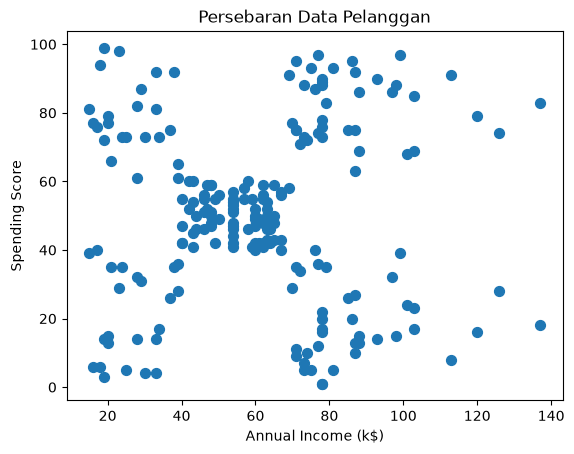

In [176]:
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Persebaran Data Pelanggan")
plt.show()

## Mencari jumlah K yang paling bagus dengan elbow method

In [177]:
wcss = [] # Within Cluster Sum of Squares

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, init = 'k-means++')
    kmeans.fit(X)

    print(kmeans.inertia_)
    wcss.append(kmeans.inertia_)

269981.28
181363.595959596
106348.37306211119
82472.19413919415
66698.05471938172
37265.86520484347
35620.04757113042
31470.110226323377
22755.686349775024


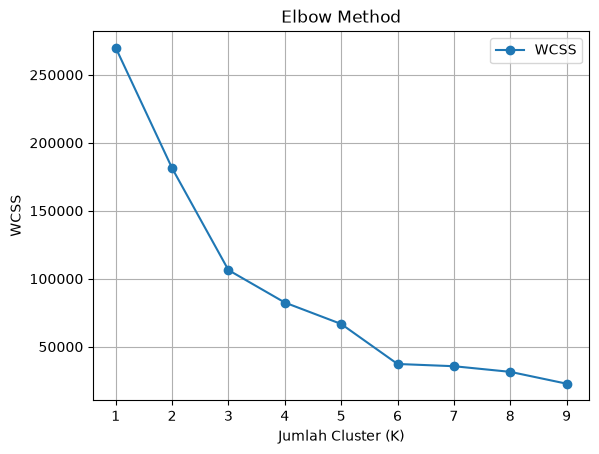

In [178]:
plt.plot(range(1,10), wcss, marker='o', label='WCSS')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.legend()
plt.grid(True)

In [179]:
kmeans = KMeans(n_clusters=5, init='k-means++')
kmeans.fit(X)

y = kmeans.predict(X)
y

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 2,
       4, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 1, 3, 2, 3, 1, 3, 1, 3,
       2, 3, 1, 3, 1, 3, 1, 3, 1, 3, 2, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3], dtype=int32)

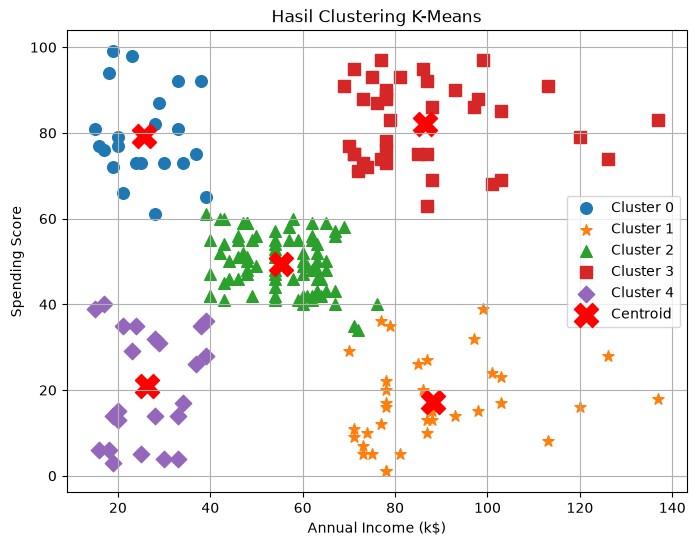

In [ ]:
markers = ['o', '*', '^', 's', 'D']

plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        marker=markers[i],
        s=70,
        label=f'Cluster {i}'
    )

# Centroid tetap X merah
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=300,
    c='red',
    label='Centroid'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Hasil Clustering K-Means")
plt.legend()
plt.grid(True)

plt.show()